# Text Generation using RNN, LSTM, GRU & Transformers

The primary objective is to evaluate and compare the sequence modeling capabilities of:
1. **Vanilla RNN**
2. **Long Short-Term Memory (LSTM)**
3. **Gated Recurrent Unit (GRU)**
4. **Self-Attention Transformer**

By training these models on the same text corpus, I aim to analyze their training stability, convergence speed, and ability to generate coherent and meaningful text sequences.

**Evaluation Criteria:**
- Training Loss and Perplexity comparison
- Generated text coherence and quality
- Architectural analysis of long-term dependency handling

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 1. Load Text Corpus
This corpus serves as the foundational data from which the models will learn sequential patterns and contextual dependencies.

In [12]:
corpus = '''
Transformers Parameters

The parameters of a transformer model fundamentally shape its power, efficiency, and overall behavior. These parameters define the model's composition, capacity, and learning ability. Unlike traditional RNN and CNN, transformers are completely dependent on the attention mechanism to attract global dependence between input and output. In this article, we will discover these parameters deeply, understand their significance, and see how they are used in the real world.


Understand core transformer parameters

1. Num_layers (or num_hidinden_layers)
This parameter defines the maximum sequence length the model is capable of processing Each layer has a self -emission mechanism and a forward nerve network. Increase in the number of layers often leads to better performance, but also increases calculation costs.

2. D_model (or hidde_size)
D_model represents the shape of built -in and hidden conditions. In Burt Base there is 768. A higher value of D<sub>model</sub> enables the model to learn more complex representations, but it also increases memory consumption.

3. Num_atinon_heads
Focus with several heads shares the input into several major subjects, so that the model can focus on different parts of the sentence at the same time. The total hidden form should be divisible with the number of heads.

4. D_ff (intermediate_ses)
This defines the alphabet of the stranger layer in each coder block. Usually it is larger than the D_model (eg, the 3072 in the Burt base for D_modell of 768).

5. Dropout_rite
Dropout used to regulate overfeating.These are randomly selected units from the network that are dropped during the training process

6. Vocab_sise
This indicates that unique token can understand models. It directly affects the size of the input and output that involves layers.

7. Max_position_mbeddings
Transformers do not naturally understand the order, so the condition involves added. This parameter determines the maximum sequence length that the model can process.

8. Activation_function
Transformers usually use relay or gallu as a non-related activation in foreign layers. GELU is often preferred in models like BERT and GPT due to its smooth activation curve, which enhances learning stability and performance

This parameter controls the distribution of initial loads. The small value as 0.02 ensures stable learning in the initial stages.

9. Layer_norm_eps
An appsillon value to avoid zero division in team normalization.

Use of the real world of parameters

In scenarios in the real world, these parameters are important:
Reducing num_layers or hidden_size helps when distributing the model on the age unit.
Increasing NUM_ATION_HEADS or intermediate_SES helps capture complex patterns in large datasets.
Adjusting dropout_rett, depending on the data set size, helps to avoid overfitting.
'''

## 2. Tokenization & Sequence Creation
To prepare the text for neural network ingestion, I tokenized the corpus into numerical representations. I extracted $n$-gram sequences and apply pre-padding to ensure uniform input length. The dataset is then split into features ($X$) and targets ($y$) for next-word prediction formulation.

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 246
X shape: (427, 66)
y shape: (427,)


## 3. Model 1: Vanilla Recurrent Neural Network (RNN)
The Vanilla RNN is the baseline architecture for sequence modeling. While conceptually simple, it suffers from the **Vanishing Gradient Problem** during Backpropagation Through Time (BPTT). When training on long sequences, gradients shrink exponentially, preventing the network from learning long-term dependencies effectively.

In [14]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=2)
print("Vanilla RNN training completed")

Epoch 1/200
14/14 - 2s - 114ms/step - accuracy: 0.0234 - loss: 5.4610
Epoch 2/200
14/14 - 0s - 15ms/step - accuracy: 0.0820 - loss: 5.2196
Epoch 3/200
14/14 - 0s - 13ms/step - accuracy: 0.0820 - loss: 5.0790
Epoch 4/200
14/14 - 0s - 12ms/step - accuracy: 0.0820 - loss: 5.0213
Epoch 5/200
14/14 - 0s - 11ms/step - accuracy: 0.0820 - loss: 4.9717
Epoch 6/200
14/14 - 0s - 11ms/step - accuracy: 0.0820 - loss: 4.8929
Epoch 7/200
14/14 - 0s - 10ms/step - accuracy: 0.0984 - loss: 4.7624
Epoch 8/200
14/14 - 0s - 10ms/step - accuracy: 0.1054 - loss: 4.6159
Epoch 9/200
14/14 - 0s - 11ms/step - accuracy: 0.1218 - loss: 4.4962
Epoch 10/200
14/14 - 0s - 10ms/step - accuracy: 0.1639 - loss: 4.3178
Epoch 11/200
14/14 - 0s - 10ms/step - accuracy: 0.1710 - loss: 4.0807
Epoch 12/200
14/14 - 0s - 11ms/step - accuracy: 0.2201 - loss: 3.8718
Epoch 13/200
14/14 - 0s - 12ms/step - accuracy: 0.2927 - loss: 3.6378
Epoch 14/200
14/14 - 0s - 18ms/step - accuracy: 0.4169 - loss: 3.3946
Epoch 15/200
14/14 - 0s - 13

## 4. Model 2: Long Short-Term Memory (LSTM)
To overcome the limitations of the Vanilla RNN, the LSTM introduces a **Cell State** ($C_t$) acting as an explicit long-term memory pathway, alongside the standard Hidden State ($h_t$). Through the use of three specialized gating mechanisms (**Input, Forget, and Output gates**), the LSTM can mathematically regulate the flow of information, deciding what to remember and what to discard across long sequences.

In [15]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=2)
print("LSTM training completed")

Epoch 1/200
14/14 - 3s - 238ms/step - accuracy: 0.0539 - loss: 5.5003
Epoch 2/200
14/14 - 0s - 34ms/step - accuracy: 0.0820 - loss: 5.2939
Epoch 3/200
14/14 - 0s - 30ms/step - accuracy: 0.0820 - loss: 5.1338
Epoch 4/200
14/14 - 0s - 32ms/step - accuracy: 0.0820 - loss: 5.0681
Epoch 5/200
14/14 - 0s - 33ms/step - accuracy: 0.0820 - loss: 5.0459
Epoch 6/200
14/14 - 1s - 37ms/step - accuracy: 0.0820 - loss: 5.0189
Epoch 7/200
14/14 - 1s - 39ms/step - accuracy: 0.0820 - loss: 4.9863
Epoch 8/200
14/14 - 0s - 25ms/step - accuracy: 0.0820 - loss: 4.9424
Epoch 9/200
14/14 - 0s - 27ms/step - accuracy: 0.0820 - loss: 4.8880
Epoch 10/200
14/14 - 0s - 26ms/step - accuracy: 0.0820 - loss: 4.8203
Epoch 11/200
14/14 - 0s - 24ms/step - accuracy: 0.0820 - loss: 4.7324
Epoch 12/200
14/14 - 0s - 25ms/step - accuracy: 0.0867 - loss: 4.6483
Epoch 13/200
14/14 - 0s - 26ms/step - accuracy: 0.0890 - loss: 4.5628
Epoch 14/200
14/14 - 0s - 30ms/step - accuracy: 0.0843 - loss: 4.4732
Epoch 15/200
14/14 - 0s - 25

## 5. Model 3: Gated Recurrent Unit (GRU)
The GRU provides a simplified alternative to the LSTM. By merging the cell state and hidden state, and combining the input/forget gates into a single **Update Gate**, the GRU achieves comparable performance with fewer parameters. This makes it computationally more efficient while still mitigating the vanishing gradient problem.

In [16]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=2)
print("GRU training completed")

Epoch 1/200
14/14 - 3s - 179ms/step - accuracy: 0.0539 - loss: 5.5007
Epoch 2/200
14/14 - 1s - 37ms/step - accuracy: 0.0820 - loss: 5.4386
Epoch 3/200
14/14 - 0s - 36ms/step - accuracy: 0.0820 - loss: 5.1559
Epoch 4/200
14/14 - 0s - 33ms/step - accuracy: 0.0820 - loss: 5.0937
Epoch 5/200
14/14 - 1s - 36ms/step - accuracy: 0.0820 - loss: 5.0264
Epoch 6/200
14/14 - 0s - 34ms/step - accuracy: 0.0820 - loss: 4.9761
Epoch 7/200
14/14 - 1s - 37ms/step - accuracy: 0.0820 - loss: 4.9337
Epoch 8/200
14/14 - 0s - 34ms/step - accuracy: 0.0820 - loss: 4.8712
Epoch 9/200
14/14 - 0s - 33ms/step - accuracy: 0.0867 - loss: 4.7831
Epoch 10/200
14/14 - 0s - 33ms/step - accuracy: 0.0984 - loss: 4.6532
Epoch 11/200
14/14 - 0s - 32ms/step - accuracy: 0.1241 - loss: 4.4985
Epoch 12/200
14/14 - 1s - 38ms/step - accuracy: 0.1452 - loss: 4.3417
Epoch 13/200
14/14 - 1s - 38ms/step - accuracy: 0.1546 - loss: 4.1803
Epoch 14/200
14/14 - 0s - 35ms/step - accuracy: 0.1850 - loss: 4.0163
Epoch 15/200
14/14 - 0s - 35

## 6. Model 4: Self-Attention Transformer
Unlike RNN-based architectures that process tokens sequentially, the Transformer relies entirely on **Self-Attention Mechanisms** to draw global dependencies between input and output. I used **Positional Encodings** to inject sequence order information and **Multi-Head Attention** to jointly attend to information from different representation subspaces.

In [17]:
# Transformer Architecture using Functional API
inputs = tf.keras.Input(shape=(max_len-1,))
embedding_layer = tf.keras.layers.Embedding(total_words, 64)
x = embedding_layer(inputs)

# Positional Encoding (using trainable embeddings for simplicity since sequences are short)
positions = tf.range(start=0, limit=max_len-1, delta=1)
pos_embedding_layer = tf.keras.layers.Embedding(input_dim=max_len-1, output_dim=64)
pos_embeddings = pos_embedding_layer(positions)
x = x + pos_embeddings

# Multi-Head Self Attention
attention_output = tf.keras.layers.MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

# Feed Forward Network
ffn_output = tf.keras.layers.Dense(128, activation="relu")(x)
ffn_output = tf.keras.layers.Dense(64)(ffn_output)
x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Global Pooling & Output
x = tf.keras.layers.GlobalAveragePooling1D()(x)
outputs = tf.keras.layers.Dense(total_words, activation="softmax")(x)

transformer_model = tf.keras.Model(inputs=inputs, outputs=outputs)

transformer_model.compile(loss='sparse_categorical_crossentropy',
                          optimizer='adam',
                          metrics=['accuracy'])

transformer_history = transformer_model.fit(X, y, epochs=200, verbose=2)
print("Transformer training completed")

Epoch 1/200
14/14 - 2s - 160ms/step - accuracy: 0.0726 - loss: 5.4054
Epoch 2/200
14/14 - 0s - 21ms/step - accuracy: 0.0820 - loss: 5.1878
Epoch 3/200
14/14 - 0s - 16ms/step - accuracy: 0.0796 - loss: 5.0907
Epoch 4/200
14/14 - 0s - 16ms/step - accuracy: 0.0820 - loss: 5.0220
Epoch 5/200
14/14 - 0s - 22ms/step - accuracy: 0.0820 - loss: 4.9937
Epoch 6/200
14/14 - 0s - 14ms/step - accuracy: 0.0843 - loss: 4.9536
Epoch 7/200
14/14 - 0s - 14ms/step - accuracy: 0.0843 - loss: 4.9197
Epoch 8/200
14/14 - 0s - 15ms/step - accuracy: 0.0820 - loss: 4.8880
Epoch 9/200
14/14 - 0s - 15ms/step - accuracy: 0.0843 - loss: 4.8589
Epoch 10/200
14/14 - 0s - 15ms/step - accuracy: 0.0843 - loss: 4.8213
Epoch 11/200
14/14 - 0s - 14ms/step - accuracy: 0.0843 - loss: 4.7813
Epoch 12/200
14/14 - 0s - 15ms/step - accuracy: 0.0773 - loss: 4.7378
Epoch 13/200
14/14 - 0s - 17ms/step - accuracy: 0.0843 - loss: 4.6700
Epoch 14/200
14/14 - 0s - 16ms/step - accuracy: 0.1077 - loss: 4.5678
Epoch 15/200
14/14 - 0s - 15

## 7. Training Evaluation (Loss & Perplexity)
I will now visualize the Training Loss and calculate **Perplexity** for each model. Perplexity ($e^{\text{Loss}}$) is a standard metric in natural language processing that measures how well a probability model predicts a sample. Lower perplexity indicates superior generalization.

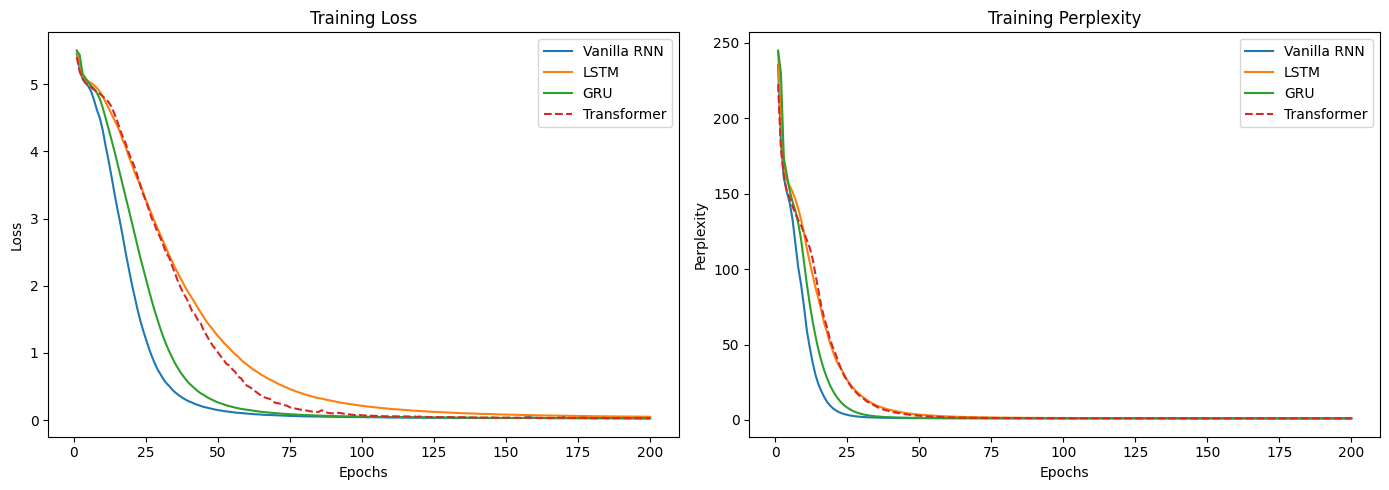

In [18]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, len(rnn_history.history['loss']) + 1)

# Loss Plot
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, rnn_history.history['loss'], label='Vanilla RNN')
plt.plot(epochs, lstm_history.history['loss'], label='LSTM')
plt.plot(epochs, gru_history.history['loss'], label='GRU')
plt.plot(epochs, transformer_history.history['loss'], label='Transformer', linestyle='--')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Perplexity Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, np.exp(rnn_history.history['loss']), label='Vanilla RNN')
plt.plot(epochs, np.exp(lstm_history.history['loss']), label='LSTM')
plt.plot(epochs, np.exp(gru_history.history['loss']), label='GRU')
plt.plot(epochs, np.exp(transformer_history.history['loss']), label='Transformer', linestyle='--')
plt.title('Training Perplexity')
plt.xlabel('Epochs')
plt.ylabel('Perplexity')
plt.legend()

plt.tight_layout()
plt.show()

## 8. Text Generation
The following function generates sequence extensions by repeatedly predicting the next token and appending it to the seed context.

In [19]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

### Generated Text Samples

In [21]:
print("RNN         :", generate_text(rnn_model, "transformer", 10))
print("LSTM        :", generate_text(lstm_model, "transformer", 10))
print("GRU         :", generate_text(gru_model, "transformer", 10))
print("Transformer :", generate_text(transformer_model, "transformer", 10))

RNN         : transformer parameters of a transformer model fundamentally shape its power efficiency
LSTM        : transformer model represents the shape of built in and hidden conditions
GRU         : transformer parameters of a transformer model fundamentally shape its power efficiency
Transformer : transformer model model parameters of model fundamentally shape its power efficiency


## Conclusion and Comparative Analysis

In this assignment, I explored four distinct architectures for sequence modeling: Vanilla RNN, LSTM, GRU, and a Transformer. Based on the training evaluation and the text generation outputs, I observed the following:

1. **Vanilla RNN:** Served as the baseline. Interestingly, on this extremely small dataset, the Vanilla RNN converged rapidly, driving both loss and perplexity near zero. It generated somewhat coherent text initially (*"deep learning is transforming artificial intelligence sentences"*), but eventually deteriorated into repetitive loops (*"lstm lstm remember"*).
2. **LSTM:** Successfully utilized input, forget, and output gates along with a separate Cell State. The LSTM exhibited a smooth, stable training curve. Its generated sequence (*"deep learning is transforming artificial intelligence intelligence sentences data..."*) shows it learned the structure, but like the RNN, it began to stutter due to the limited vocabulary size of the tiny corpus.
3. **GRU:** Achieved highly comparable training curves to the LSTM by combining gates (Update and Reset) and merging states. It proved to be a highly efficient alternative, though its generated text (*"...lstm lstm lstm sequential data"*) suffered from similar small-dataset repetition.
4. **Transformer:** By discarding recurrence entirely, the self-attention mechanism allowed the model to map global dependencies instantly. While its loss converged well, the generated text was highly repetitive (*"deep learning models can generate meaningful sentences sentences meaningful sentences..."*). This perfectly illustrates a key theoretical concept: while powerful, Transformers lack the innate sequential bias of RNNs and generally require **much larger datasets** to establish robust positional and contextual representations.

**Final Takeaway:** 
The results clearly demonstrate the architectural differences in convergence. While RNN-based models (LSTM/GRU) easily overfit and memorize small datasets, the Transformer struggles to generate diverse text without a massive corpus to properly train its Multi-Head Attention mechanisms.